Fetching market data...


/tmp/ipykernel_6511/4052548586.py:45: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
/tmp/ipykernel_6511/4052548586.py:48: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
/tmp/ipykernel_6511/4052548586.py:62: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  d = datetime.utcfromtimestamp(float(ts)/1000

  ETH: 365 days  |  BTC: 365 days  |  Volume: 365 days

Fetching whale transactions (365 days takes a few minutes)...
  Scanning Binance 7...
    → 753 txs
  Scanning Robinhood...
    → 194 txs
  Scanning Upbit 41...
    → 10000 txs
  Scanning Gemini: Cold Wallet...
    → 504 txs
  Scanning Bitfinex 19...
    → 60 txs
  Scanning Robinhood 6...
    → 399 txs
  Scanning Kraken: Cold Wallet 4...
    → 21 txs
  Scanning Binance: Hot Wallet 20...
    → 3127 txs
  Scanning Vb 3...
    → 301 txs
  Scanning Kraken: Cold Wallet 3...
    → 131 txs

Analyzing...

  WHALE WALLET IMPACT MODEL — SUMMARY
  Period          : Last 365 days
  Whale wallets   : 10
  Whale threshold : > 50 ETH per tx
  Whale buy days  : 134
  Whale sell days : 61

  ETH price change after whale BUY DAYS:
    +0d : N/A
    +1d : ▲ +0.1578%
    +2d : ▲ +0.0805%
    +3d : ▲ +0.2100%

  ETH price change after whale SELL DAYS:
    +0d : N/A
    +1d : ▲ +0.0564%
    +2d : ▲ +0.4572%
    +3d : ▲ +0.3639%

  Top 5 biggest whale m

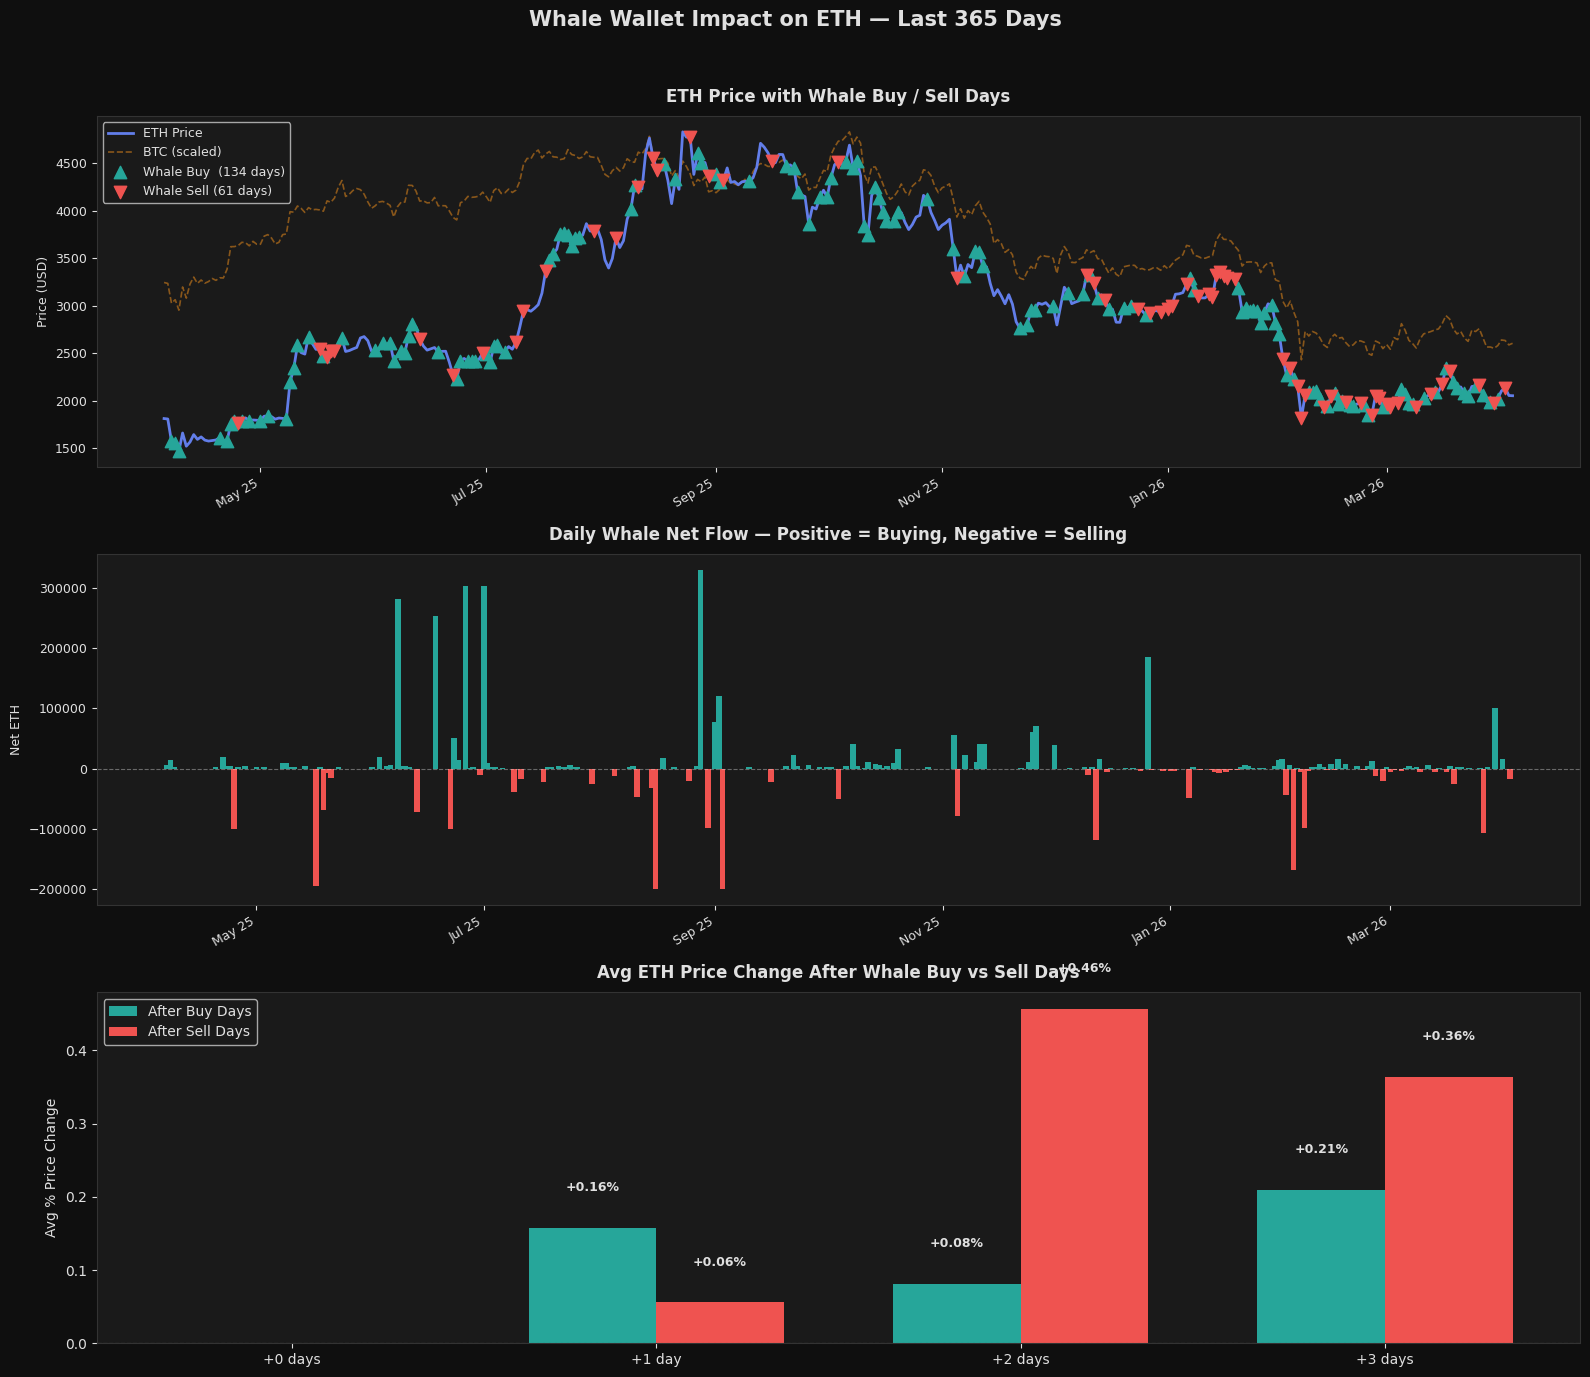

  Chart saved → whale_impact_report.png


In [3]:
import requests
import time
from decimal import Decimal
from datetime import datetime, timedelta
from collections import defaultdict
import statistics
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Config ────────────────────────────────────────────────────────────────────

ETHERSCAN_KEY   = "2M4Z6AH3QBFCIXPCJHCQ2F12S1CFWIEZKJ"
ETHERSCAN_URL   = "https://api.etherscan.io/v2/api"
COINGECKO_URL   = "https://api.coingecko.com/api/v3"
WEI_TO_ETH      = Decimal("1e18")

WHALE_THRESHOLD = Decimal("50")   # ETH — tx above this counts as whale move
DAYS_TO_ANALYZE = 365             # ← change to 30, 90, 180, or 365
LAG_DAYS        = [0, 1, 2, 3]

WHALE_WALLETS = {
    "0xbe0eb53f46cd790cd13851d5eff43d12404d33e8": "Binance 7",
    "0x40b38765696e3d5d8d9d834d8aad4bb6e418e489": "Robinhood",
    "0x0e58e8993100f1cbe45376c410f97f4893d9bfcd": "Upbit 41",
    "0xafcd96e580138cfa2332c632e66308eacd45c5da": "Gemini: Cold Wallet",
    "0xe92d1a43df510f82c66382592a047d288f85226f": "Bitfinex 19",
    "0x73af3bcf944a6559933396c1577b257e2054d935": "Robinhood 6",
    "0x9f1799fb47b1514f453bcebbc37ecfe883756e83": "Kraken: Cold Wallet 4",
    "0xf977814e90da44bfa03b6295a0616a897441acec": "Binance: Hot Wallet 20",
    "0x220866b1a2219f40e72f5c628b65d54268ca3a9d": "Vb 3",
    "0x8d05d9924fe935bd533a844271a1b2078eae6fcf": "Kraken: Cold Wallet 3",
}


# ── Data Fetching ─────────────────────────────────────────────────────────────

def get_eth_market_history(days=DAYS_TO_ANALYZE):
    """Fetch ETH price + volume. CoinGecko free tier supports up to 365 days."""
    url    = f"{COINGECKO_URL}/coins/ethereum/market_chart"
    params = {"vs_currency": "usd", "days": days, "interval": "daily"}
    prices, volumes = {}, {}
    try:
        data = requests.get(url, params=params, timeout=10).json()
        for ts, p in data.get("prices", []):
            d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
            prices[d] = float(p)
        for ts, v in data.get("total_volumes", []):
            d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
            volumes[d] = float(v)
    except Exception as e:
        print(f"[!] CoinGecko ETH error: {e}")
    return prices, volumes


def get_btc_price_history(days=DAYS_TO_ANALYZE):
    url    = f"{COINGECKO_URL}/coins/bitcoin/market_chart"
    params = {"vs_currency": "usd", "days": days, "interval": "daily"}
    prices = {}
    try:
        data = requests.get(url, params=params, timeout=10).json()
        for ts, p in data.get("prices", []):
            d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
            prices[d] = float(p)
    except Exception as e:
        print(f"[!] CoinGecko BTC error: {e}")
    return prices


def get_whale_transactions(address, days=DAYS_TO_ANALYZE):
    """
    Fetch whale transactions. For 365 days, Etherscan may return up to 10k txs
    per address — pagination handles the rest automatically.
    """
    cutoff  = int((datetime.now() - timedelta(days=days)).timestamp())
    all_txs = []
    page    = 1
    while True:
        params = {
            "chainid": 1, "module": "account", "action": "txlist",
            "address": address, "startblock": 0, "endblock": 99999999,
            "page": page, "offset": 1000, "sort": "desc", "apikey": ETHERSCAN_KEY,
        }
        try:
            data = requests.get(ETHERSCAN_URL, params=params, timeout=10).json()
        except Exception as e:
            print(f"  [!] Request error: {e}"); break

        if data["status"] != "1":
            break
        txs = [t for t in data["result"] if int(t["timeStamp"]) >= cutoff]
        all_txs.extend(txs)
        if len(data["result"]) < 1000 or int(data["result"][-1]["timeStamp"]) < cutoff:
            break
        page += 1
        time.sleep(0.25)
    return all_txs


# ── Analysis ──────────────────────────────────────────────────────────────────

def classify_whale_days(all_whale_txs):
    daily = defaultdict(lambda: {"inflow": Decimal(0), "outflow": Decimal(0), "tx_count": 0})
    for address, txs in all_whale_txs.items():
        for tx in txs:
            val = Decimal(tx["value"]) / WEI_TO_ETH
            if val < WHALE_THRESHOLD or tx.get("isError") == "1":
                continue
            date = datetime.fromtimestamp(int(tx["timeStamp"])).strftime("%Y-%m-%d")
            if tx["to"].lower() == address.lower():
                daily[date]["inflow"]  += val
            elif tx["from"].lower() == address.lower():
                daily[date]["outflow"] += val
            daily[date]["tx_count"] += 1
    for d in daily:
        daily[d]["net_flow"] = daily[d]["inflow"] - daily[d]["outflow"]
    return dict(daily)


def price_change(prices, date, lag):
    dates = sorted(prices.keys())
    if date not in dates: return None
    idx = dates.index(date)
    if idx + lag >= len(dates): return None
    p0, p1 = prices[date], prices[dates[idx + lag]]
    return ((p1 - p0) / p0) * 100 if p0 else None


def build_results(whale_days, eth_prices, volumes, btc_prices):
    avg_vol = statistics.mean(volumes.values()) if volumes else 1
    results = []
    for date, wd in sorted(whale_days.items()):
        net    = float(wd["net_flow"])
        signal = "ACCUMULATE" if net > 0 else "DISTRIBUTE"
        chgs   = {f"eth_chg_d{l}": (lambda c: round(c,4) if c else None)(price_change(eth_prices, date, l)) for l in LAG_DAYS}
        results.append({
            "date":      date,
            "signal":    signal,
            "net_flow":  round(net, 2),
            "inflow":    round(float(wd["inflow"]),  2),
            "outflow":   round(float(wd["outflow"]), 2),
            "whale_txs": wd["tx_count"],
            "eth_price": round(eth_prices.get(date, 0), 2),
            "btc_price": round(btc_prices.get(date, 0), 2),
            "vol_ratio": round(volumes.get(date, 0) / avg_vol, 3),
            "btc_chg_d1": (lambda c: round(c,4) if c else None)(price_change(btc_prices, date, 1)),
            **chgs,
        })
    return results


# ── Plotting ──────────────────────────────────────────────────────────────────

DARK  = "#0f0f0f"
PANEL = "#1a1a1a"
GREEN = "#26a69a"
RED   = "#ef5350"
BLUE  = "#627eea"
ORANGE= "#f7931a"
WHITE = "#e0e0e0"

def style(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=WHITE, fontsize=12, fontweight="bold", pad=10)
    ax.tick_params(colors=WHITE, labelsize=9)
    ax.set_xlabel(xlabel, color=WHITE, fontsize=9)
    ax.set_ylabel(ylabel, color=WHITE, fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y" if DAYS_TO_ANALYZE > 90 else "%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", color=WHITE)


def plot_all(results, eth_prices, btc_prices, volumes):
    all_dates = sorted(set(eth_prices) & set(btc_prices))
    all_dt    = [datetime.strptime(d, "%Y-%m-%d") for d in all_dates]
    eth_vals  = [eth_prices[d] for d in all_dates]
    vol_vals  = [volumes.get(d, 0) / 1e9 for d in all_dates]  # billions

    # Normalise BTC to ETH scale for overlay
    btc_norm  = [btc_prices[d] / max(btc_prices.values()) * max(eth_prices.values()) for d in all_dates]

    acc_rows  = [r for r in results if r["signal"] == "ACCUMULATE"]
    dist_rows = [r for r in results if r["signal"] == "DISTRIBUTE"]

    acc_dt    = [datetime.strptime(r["date"], "%Y-%m-%d") for r in acc_rows]
    dist_dt   = [datetime.strptime(r["date"], "%Y-%m-%d") for r in dist_rows]
    acc_px    = [r["eth_price"] for r in acc_rows]
    dist_px   = [r["eth_price"] for r in dist_rows]

    def avg_lag(rows, lag):
        vals = [r[f"eth_chg_d{lag}"] for r in rows if r.get(f"eth_chg_d{lag}") is not None]
        return round(statistics.mean(vals), 3) if vals else 0

    fig, axes = plt.subplots(3, 1, figsize=(16, 14), facecolor=DARK)
    fig.suptitle(
        f"Whale Wallet Impact on ETH — Last {DAYS_TO_ANALYZE} Days",
        color=WHITE, fontsize=15, fontweight="bold", y=0.98
    )

    # ── Chart 1: ETH price + BTC overlay + whale signals ──
    ax1 = axes[0]
    style(ax1, "ETH Price with Whale Buy / Sell Days", ylabel="Price (USD)")
    ax1.plot(all_dt, eth_vals,  color=BLUE,   lw=2,   label="ETH Price", zorder=2)
    ax1.plot(all_dt, btc_norm,  color=ORANGE, lw=1.2, linestyle="--", alpha=0.5, label="BTC (scaled)", zorder=1)
    ax1.scatter(acc_dt,  acc_px,  color=GREEN, s=80, zorder=5, marker="^", label=f"Whale Buy  ({len(acc_rows)} days)")
    ax1.scatter(dist_dt, dist_px, color=RED,   s=80, zorder=5, marker="v", label=f"Whale Sell ({len(dist_rows)} days)")
    ax1.legend(facecolor=PANEL, labelcolor=WHITE, fontsize=9, loc="upper left")
    ax1.yaxis.label.set_color(WHITE)

    # ── Chart 2: Whale net flow (buy/sell volume per day) ──
    ax2 = axes[1]
    style(ax2, "Daily Whale Net Flow — Positive = Buying, Negative = Selling", ylabel="Net ETH")
    dates_dt   = [datetime.strptime(r["date"], "%Y-%m-%d") for r in results]
    net_flows  = [r["net_flow"] for r in results]
    colors     = [GREEN if n > 0 else RED for n in net_flows]
    ax2.bar(dates_dt, net_flows, color=colors, width=1.5, zorder=2)
    ax2.axhline(0, color=WHITE, lw=0.8, alpha=0.4, linestyle="--")
    ax2.yaxis.label.set_color(WHITE)

    # ── Chart 3: Avg ETH % change at each lag after buy vs sell days ──
    ax3 = axes[2]
    ax3.set_facecolor(PANEL)
    ax3.set_title("Avg ETH Price Change After Whale Buy vs Sell Days", color=WHITE, fontsize=12, fontweight="bold", pad=10)
    ax3.tick_params(colors=WHITE, labelsize=10)
    for spine in ax3.spines.values():
        spine.set_edgecolor("#333")

    lag_labels = [f"+{l} day{'s' if l != 1 else ''}" for l in LAG_DAYS]
    x = range(len(LAG_DAYS))
    w = 0.35

    acc_vals  = [avg_lag(acc_rows,  l) for l in LAG_DAYS]
    dist_vals = [avg_lag(dist_rows, l) for l in LAG_DAYS]

    b_acc  = ax3.bar([p - w/2 for p in x], acc_vals,  width=w, color=GREEN, label="After Buy Days",  zorder=2)
    b_dist = ax3.bar([p + w/2 for p in x], dist_vals, width=w, color=RED,   label="After Sell Days", zorder=2)
    ax3.axhline(0, color=WHITE, lw=0.8, alpha=0.4, linestyle="--")
    ax3.set_xticks(list(x))
    ax3.set_xticklabels(lag_labels, color=WHITE, fontsize=10)
    ax3.set_ylabel("Avg % Price Change", color=WHITE, fontsize=10)
    ax3.legend(facecolor=PANEL, labelcolor=WHITE, fontsize=10)

    for bar in list(b_acc) + list(b_dist):
        h = bar.get_height()
        if h != 0:
            ax3.text(
                bar.get_x() + bar.get_width() / 2,
                h + (0.05 if h >= 0 else -0.15),
                f"{h:+.2f}%", ha="center", color=WHITE, fontsize=9, fontweight="bold"
            )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("whale_impact_report.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("  Chart saved → whale_impact_report.png")


# ── Summary Print ─────────────────────────────────────────────────────────────

def summarize(results, eth_prices, btc_prices):
    acc  = [r for r in results if r["signal"] == "ACCUMULATE"]
    dist = [r for r in results if r["signal"] == "DISTRIBUTE"]

    def avg(rows, key):
        vals = [r[key] for r in rows if r.get(key) is not None]
        return round(statistics.mean(vals), 4) if vals else None

    print("\n" + "="*65)
    print("  WHALE WALLET IMPACT MODEL — SUMMARY")
    print("="*65)
    print(f"  Period          : Last {DAYS_TO_ANALYZE} days")
    print(f"  Whale wallets   : {len(WHALE_WALLETS)}")
    print(f"  Whale threshold : > {WHALE_THRESHOLD} ETH per tx")
    print(f"  Whale buy days  : {len(acc)}")
    print(f"  Whale sell days : {len(dist)}")

    for label, rows in [("BUY DAYS", acc), ("SELL DAYS", dist)]:
        print(f"\n  ETH price change after whale {label}:")
        for lag in LAG_DAYS:
            c = avg(rows, f"eth_chg_d{lag}")
            print(f"    +{lag}d : {'▲' if c and c > 0 else '▼'} {c:>+.4f}%" if c else f"    +{lag}d : N/A")

    print(f"\n  Top 5 biggest whale moves:")
    for r in sorted(results, key=lambda x: abs(x["net_flow"]), reverse=True)[:5]:
        e = r.get("eth_chg_d1")
        print(f"  {r['date']}  {'BUY ':5s} {r['net_flow']:>12.0f} ETH  ETH next day: {f'{e:+.2f}%' if e else 'N/A'}"
              if r["signal"] == "ACCUMULATE" else
              f"  {r['date']}  {'SELL':5s} {r['net_flow']:>12.0f} ETH  ETH next day: {f'{e:+.2f}%' if e else 'N/A'}")

    print(f"\n  Interpretation:")
    a1 = avg(acc,  "eth_chg_d1")
    d1 = avg(dist, "eth_chg_d1")
    if a1: print(f"  {'✓' if a1 > 0 else '✗'} Whale buying  → ETH {'rises' if a1 > 0 else 'falls'} next day on avg ({a1:+.2f}%)")
    if d1: print(f"  {'✓' if d1 < 0 else '✗'} Whale selling → ETH {'drops' if d1 < 0 else 'rises'} next day on avg ({d1:+.2f}%)")
    print()


# ── Main ──────────────────────────────────────────────────────────────────────

print("Fetching market data...")
eth_prices, volumes = get_eth_market_history(DAYS_TO_ANALYZE)
btc_prices          = get_btc_price_history(DAYS_TO_ANALYZE)
print(f"  ETH: {len(eth_prices)} days  |  BTC: {len(btc_prices)} days  |  Volume: {len(volumes)} days")

print("\nFetching whale transactions (365 days takes a few minutes)...")
all_whale_txs = {}
for address, name in WHALE_WALLETS.items():
    print(f"  Scanning {name}...")
    txs = get_whale_transactions(address, DAYS_TO_ANALYZE)
    all_whale_txs[address] = txs
    print(f"    → {len(txs)} txs")
    time.sleep(0.3)

print("\nAnalyzing...")
whale_days = classify_whale_days(all_whale_txs)
results    = build_results(whale_days, eth_prices, volumes, btc_prices)
summarize(results, eth_prices, btc_prices)
plot_all(results, eth_prices, btc_prices, volumes)